# Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
print("Google Drive mounted successfully")

# Install *YOLOv8*

In [ ]:
!pip install ultralytics

# Dataset to Colab

In [ ]:
import shutil
import os
from tqdm import tqdm
import time

source_path = '/content/drive/MyDrive/ml_pest'
destination_path = '/content/dataset'

# Calculate total size for progress estimation
total_size = 0
for dirpath, dirnames, filenames in os.walk(source_path):
    for f in filenames:
        fp = os.path.join(dirpath, f)
        total_size += os.path.getsize(fp)

total_size_mb = total_size / (1024 * 1024)
print(f"Total dataset size: {total_size_mb:.1f} MB")
print(f"Estimated time: {total_size_mb / 200:.1f} minutes")

print("Starting copy...")

if os.path.exists(destination_path):
    shutil.rmtree(destination_path)

# Copy with progress simulation
start_time = time.time()
shutil.copytree(source_path, destination_path)
end_time = time.time()

elapsed = end_time - start_time
print(f"Dataset copied successfully in {elapsed:.1f} seconds")

Total dataset size: 1468.0 MB
Estimated time: 7.3 minutes
Starting copy...


# EDA

train: 17553 images
valid: 4990 images
test: 2458 images
Total classes: 100
Average width: 640 pixels
Average height: 640 pixels


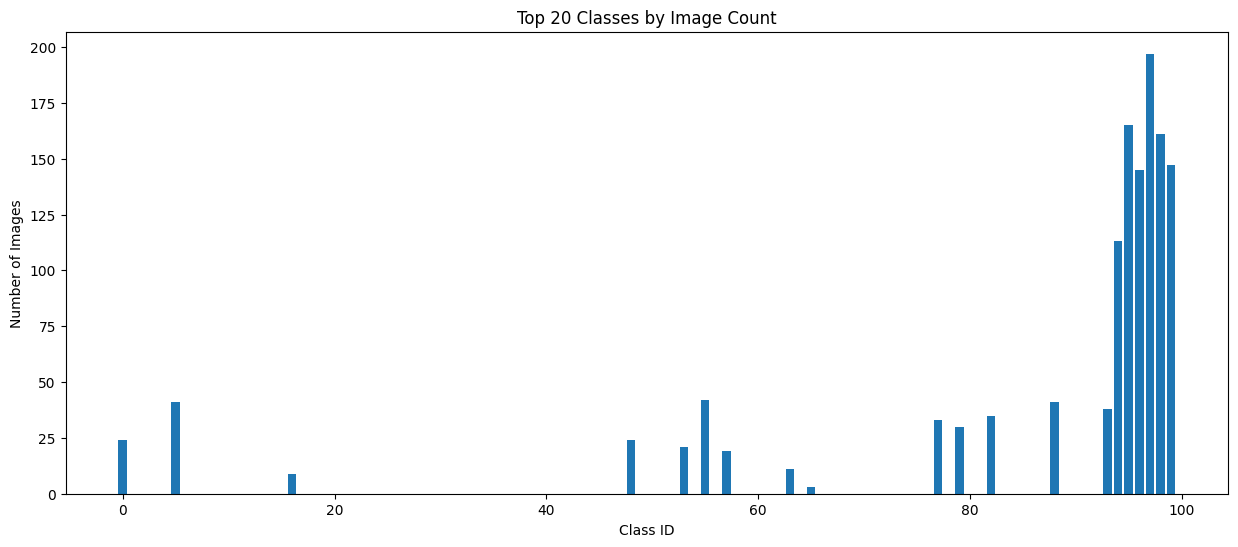

In [ ]:
import os
import cv2
import yaml
import matplotlib.pyplot as plt
import random
from collections import defaultdict

# Set the base path for train/valid/test directories to the Google Drive location
base_dataset_path = '/content/drive/MyDrive/ml_pest/picture' # Corrected to use Google Drive path

# Path to the data.yaml file
yaml_file_path = os.path.join(base_dataset_path, 'data.yaml')

# 1. Count images in each split
splits = ['train', 'valid', 'test']
for split in splits:
    img_path = os.path.join(base_dataset_path, split, 'images') # Use base_dataset_path
    count = len(os.listdir(img_path))
    print(f"{split}: {count} images")

# 2. Load class names
with open(yaml_file_path, 'r') as f: # Use explicit yaml_file_path
    data = yaml.safe_load(f)
    class_names = data['names']
    print(f"Total classes: {len(class_names)}")

# 3. Count images per class from labels
class_counts = defaultdict(int)

train_labels_path = os.path.join(base_dataset_path, 'train', 'labels') # Use base_dataset_path
for label_file in os.listdir(train_labels_path)[:1000]: # Limit to 1000 for faster EDA
    with open(os.path.join(train_labels_path, label_file), 'r') as f:
        for line in f:
            class_id = int(line.strip().split()[0])
            class_counts[class_id] += 1

# 4. Check image dimensions
sample_images = os.listdir(os.path.join(base_dataset_path, 'train', 'images'))[:100] # Use base_dataset_path
widths, heights = [], []
for img_name in sample_images:
    img = cv2.imread(os.path.join(base_dataset_path, 'train', 'images', img_name)) # Use base_dataset_path
    if img is not None:
        h, w = img.shape[:2]
        heights.append(h)
        widths.append(w)

print(f"Average width: {sum(widths)/len(widths):.0f} pixels")
print(f"Average height: {sum(heights)/len(heights):.0f} pixels")

# 5. Plot class distribution
plt.figure(figsize=(15, 6))
# Filter classes to only include those that actually have counts and take top 20
sorted_classes = sorted(class_counts.items(), key=lambda item: item[1], reverse=True)
classes_to_plot = [class_id for class_id, count in sorted_classes[:20]]
counts_to_plot = [count for class_id, count in sorted_classes[:20]]

plt.bar(classes_to_plot, counts_to_plot)
plt.title('Top 20 Classes by Image Count')
plt.xlabel('Class ID')
plt.ylabel('Number of Images')
plt.show()

# Generating dataset illustrations...

In [ ]:
import cv2
import matplotlib.pyplot as plt
import os
import random
from pathlib import Path

# Set paths
dataset_path = '/content/dataset/picture'
train_images_path = os.path.join(dataset_path, 'train', 'images')
train_labels_path = os.path.join(dataset_path, 'train', 'labels')

# Create output folder for illustrations
os.makedirs('/content/illustrations', exist_ok=True)

# Get list of all images
images = os.listdir(train_images_path)
random.shuffle(images)

print("Generating dataset illustrations...")

# Draw Bounding Boxes on Sample Images

In [ ]:
def draw_bounding_boxes(image_path, label_path, output_path):
    img = cv2.imread(image_path)
    h, w = img.shape[:2]

    if os.path.exists(label_path):
        with open(label_path, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) == 5:
                    class_id, x_center, y_center, box_w, box_h = map(float, parts)

                    # Convert YOLO coordinates to pixel coordinates
                    x1 = int((x_center - box_w/2) * w)
                    y1 = int((y_center - box_h/2) * h)
                    x2 = int((x_center + box_w/2) * w)
                    y2 = int((y_center + box_h/2) * h)

                    # Draw bounding box
                    cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
                    cv2.putText(img, f'Class {int(class_id)}', (x1, y1-5),
                                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1)

    # Convert BGR to RGB for matplotlib
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(10, 8))
    plt.imshow(img_rgb)
    plt.axis('off')
    plt.title(f'Sample Image with Bounding Boxes')
    plt.savefig(output_path, bbox_inches='tight', dpi=150)
    plt.show()
    plt.close()

# Generate 6 sample images with bounding boxes
for i, img_name in enumerate(images[:6]):
    img_path = os.path.join(train_images_path, img_name)
    label_name = img_name.replace('.jpg', '.txt').replace('.png', '.txt')
    label_path = os.path.join(train_labels_path, label_name)
    output_path = f'/content/illustrations/sample_{i+1}_with_boxes.png'
    draw_bounding_boxes(img_path, label_path, output_path)
    print(f"Saved: {output_path}")

# Class Distribution Chart

In [ ]:
import yaml
from collections import defaultdict

# Load class names from data.yaml
yaml_path = os.path.join(dataset_path, 'data.yaml')
with open(yaml_path, 'r') as f:
    data = yaml.safe_load(f)
    class_names = data['names']

# Count images per class from labels
class_counts = defaultdict(int)

for img_name in images:
    label_name = img_name.replace('.jpg', '.txt').replace('.png', '.txt')
    label_path = os.path.join(train_labels_path, label_name)

    if os.path.exists(label_path):
        with open(label_path, 'r') as f:
            for line in f:
                class_id = int(line.strip().split()[0])
                class_counts[class_id] += 1

# Create bar chart
plt.figure(figsize=(15, 6))
classes = list(class_counts.keys())
counts = list(class_counts.values())
class_labels = [class_names[c] if c < len(class_names) else f'Class {c}' for c in classes]

plt.bar(class_labels, counts, color='green', alpha=0.7)
plt.xlabel('Crop Classes', fontsize=12)
plt.ylabel('Number of Images', fontsize=12)
plt.title('Distribution of Images per Crop Class', fontsize=14)
plt.xticks(rotation=90, fontsize=8)
plt.tight_layout()
plt.show()
plt.savefig('/content/illustrations/class_distribution.png', dpi=150, bbox_inches='tight')
plt.close()

print(f"Total classes: {len(class_counts)}")
print(f"Average images per class: {sum(counts)/len(counts):.0f}")
print("Saved: class_distribution.png")

# Image Size Distribution

In [ ]:
widths = []
heights = []

for img_name in images[:500]:  # Sample 500 images for speed
    img_path = os.path.join(train_images_path, img_name)
    img = cv2.imread(img_path)
    if img is not None:
        h, w = img.shape[:2]
        heights.append(h)
        widths.append(w)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(widths, bins=30, color='blue', alpha=0.7)
plt.xlabel('Width (pixels)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Distribution of Image Widths', fontsize=14)

plt.subplot(1, 2, 2)
plt.hist(heights, bins=30, color='orange', alpha=0.7)
plt.xlabel('Height (pixels)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Distribution of Image Heights', fontsize=14)

plt.tight_layout()
plt.show()
plt.savefig('/content/illustrations/image_size_distribution.png', dpi=150, bbox_inches='tight')
plt.close()
print("Saved: image_size_distribution.png")

# Sample Augmentations

In [ ]:
import albumentations as A

# Define augmentations
transform = A.Compose([
    A.RandomRotate90(p=0.5),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.5),
])

# Pick one image
sample_img_path = os.path.join(train_images_path, images[0])
img = cv2.imread(sample_img_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Apply augmentations
augmented1 = transform(image=img)['image']
augmented2 = transform(image=img)['image']
augmented3 = transform(image=img)['image']

# Plot original and augmented
plt.figure(figsize=(15, 4))

plt.subplot(1, 4, 1)
plt.imshow(img_rgb)
plt.axis('off')
plt.title('Original Image')

plt.subplot(1, 4, 2)
plt.imshow(augmented1)
plt.axis('off')
plt.title('Rotation')

plt.subplot(1, 4, 3)
plt.imshow(augmented2)
plt.axis('off')
plt.title('Flip')

plt.subplot(1, 4, 4)
plt.imshow(augmented3)
plt.axis('off')
plt.title('Brightness Change')

plt.tight_layout()
plt.show()
plt.savefig('/content/illustrations/data_augmentation.png', dpi=150, bbox_inches='tight')
plt.close()
print("Saved: data_augmentation.png")

# Verify Dataset Structure

In [ ]:
!ls -la /content/dataset/
!cat /content/drive/MyDrive/ml_pest/picture/data.yaml

# Count images per split

In [ ]:
import os

train_images = len(os.listdir('/content/drive/MyDrive/ml_pest/picture/train/images'))
valid_images = len(os.listdir('/content/drive/MyDrive/ml_pest/picture/valid/images'))
test_images = len(os.listdir('//content/drive/MyDrive/ml_pest/picture/test/images'))

print(f"Train: {train_images} images")
print(f"Valid: {valid_images} images")
print(f"Test: {test_images} images")

# Verify one image and its label match

In [ ]:
import cv2
import numpy as np

# Check first image in train folder
img_path = '/content/drive/MyDrive/ml_pest/picture/train/images/717FeZ2PIXL_jpg.rf.9ab63a3e9bf5b150f7789037bf3c4600.jpg'
label_path = img_path.replace('images', 'labels').replace('.jpg', '.txt')

img = cv2.imread(img_path)
print(f"Image shape: {img.shape}")

if os.path.exists(label_path):
    with open(label_path, 'r') as f:
        print(f"Label content: {f.read()}")
else:
    print("Label file missing")

# Update data.yaml Paths

In [ ]:
import yaml

yaml_path = '/content/drive/MyDrive/ml_pest/picture/data.yaml'

with open(yaml_path, 'r') as f:
    data = yaml.safe_load(f)

data['train'] = '/content/drive/MyDrive/ml_pest/picture/train/images'
data['val'] = '/content/drive/MyDrive/ml_pest/picture/valid/images'
data['test'] = '/content/drive/MyDrive/ml_pest/picture/test/images'

with open(yaml_path, 'w') as f:
    yaml.dump(data, f)

print("Paths updated successfully")

# Train the Model

In [ ]:
from ultralytics import YOLO

# Load YOLOv8 nano model
model = YOLO('yolov8n.pt')

# Train the model
results = model.train(
    data='/content/drive/MyDrive/ml_pest/picture/data.yaml',
    epochs=50,
    imgsz=640,
    batch=16,
    name='pest_detection_model',
    device=0
)

print("Training completed!")

# Evaluate the Model

In [ ]:
results = model.val()
print(f"mAP50: {results.box.map50:.2f}")
print(f"mAP50-95: {results.box.map:.2f}")

# Test on a Sample Image

In [ ]:
from IPython.display import Image as IPImage

# Run detection on test images
model('/content/dataset/test/images', save=True)

# Display a result
IPImage(filename='/content/runs/detect/predict/example_image.jpg')

# Export Model for Your Server

In [ ]:
# Export to ONNX format (works without GPU on your laptop)
model.export(format='onnx', imgsz=640)

# Download the exported model to your computer
from google.colab import files
files.download('/content/runs/detect/train/weights/best.onnx')

# Download All Training Results

In [ ]:
!zip -r /content/training_results.zip /content/runs/
files.download('/content/training_results.zip')